# Notebook 04: HowNet 知識圖譜校準神經向量 (Faruqui Retrofitting)

**重大突破實驗**：依據 Faruqui et al. (2015) Retrofitting 凸優化演算法，
引入 HowNet（知網）義原符號本體作為知識引力先驗，校準 BGE 神經向量空間，
消除 BPE Next Token Prediction 所帶來的「世界表象（連結性）vs 概念本質（相似性）」混沌。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer
from scipy import stats
import OpenHowNet
from opencc import OpenCC
from pathlib import Path

# 自動相容專案根目錄與 notebooks 目錄
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = ROOT_DIR / "data" / "results"

# 讀取 Notebook 02 產出的合併成果檔
input_path = RESULTS_DIR / "02_combined_scores.csv"
df = pd.read_csv(input_path)
print(f"✅ 成功載入成果檔：共 {len(df)} 組詞對")
df.head()

/Users/yefangwong/Documents/GitHub.nosync/token-meaning-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 成功載入成果檔：共 20 組詞對


,pair_id,word1,word2,quadrant,true_similarity,true_relatedness,rationale_zh,hownet_similarity,llm_cosine
0,P01,醫生,護士,Q1,HIGH,LOW,同為醫療從業人員義原高度重疊；但無典型事件共現,0.792000,0.719874
1,P02,貓,狗,Q1,HIGH,LOW,同為哺乳類寵物；日常共現但非因果事件關係,0.865000,0.683817
2,P03,蘋果,橘子,Q1,HIGH,LOW,同為水果上位概念完全重合；無工具/場所因果連結,1.000000,0.439955
3,P04,鋼琴,吉他,Q1,HIGH,LOW,同為樂器；演奏場合偶有重疊但非強因果連結,1.000000,0.633672
4,P05,教師,教授,Q1,HIGH,LOW,同為教育工作者；職銜相似但非同一事件參與者,0.787375,0.687674


In [2]:
# 1. 取得唯一詞彙表與 BGE 原始向量
words = sorted(list(set(df["word1"].tolist() + df["word2"].tolist())))
word2idx = {w: i for i, w in enumerate(words)}
V = len(words)
print(f"詞彙表大小: {V} 個獨立詞彙")

model = SentenceTransformer("BAAI/bge-large-zh-v1.5")
raw_embs = np.array([model.encode(w, normalize_embeddings=True) for w in words])
Q_hat = raw_embs.copy()
print(f"向量維度: {Q_hat.shape}")

詞彙表大小: 30 個獨立詞彙
向量維度: (30, 1024)


In [3]:
# 2. 構建知網本體引力邊 (門檻 >= 0.70)
cc = OpenCC("t2s")
hownet_dict = OpenHowNet.HowNetDict()
hownet_dict.initialize_similarity_calculation()

W = np.zeros((V, V))
for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        if i != j:
            score = hownet_dict.calculate_word_similarity(cc.convert(w1), cc.convert(w2))
            h_sim = float(score) if score is not None and score != -1 else 0.0
            if h_sim >= 0.70:
                W[i, j] = h_sim

print(f"✅ 建立 {int(np.sum(W > 0)/2)} 對符號本體引力邊 (門檻 >= 0.70)")

Initializing OpenHowNet succeeded!
Initializing similarity calculation succeeded!
✅ 建立 29 對符號本體引力邊 (門檻 >= 0.70)


In [4]:
# 3. 執行 Faruqui Retrofitting 凸優化迭代
Q = Q_hat.copy()
alpha = 1.0
for _ in range(20):
    Q_new = np.zeros_like(Q)
    for i in range(V):
        nb = np.where(W[i] > 0)[0]
        if len(nb) == 0:
            Q_new[i] = Q_hat[i]
        else:
            w = W[i, nb]
            Q_new[i] = (alpha * Q_hat[i] + np.sum(w[:, None] * Q[nb], axis=0)) / (alpha + np.sum(w))
    norms = np.linalg.norm(Q_new, axis=1, keepdims=True)
    Q = Q_new / np.maximum(norms, 1e-12)

print("✅ 20 輪凸優化迭代完成，向量完成幾何投影重塑！")

✅ 20 輪凸優化迭代完成，向量完成幾何投影重塑！


In [5]:
# 4. 計算校準後的新餘弦相似度並存檔
df["retrofitted_cosine"] = [
    float(np.dot(Q[word2idx[r["word1"]]], Q[word2idx[r["word2"]]])) 
    for _, r in df.iterrows()
]

output_csv = RESULTS_DIR / "04_retrofitted_scores.csv"
df.to_csv(output_csv, index=False)
print(f"✅ 新分數已儲存至: {output_csv}")
df[["pair_id", "word1", "word2", "quadrant", "llm_cosine", "hownet_similarity", "retrofitted_cosine"]].head(10)

✅ 新分數已儲存至: /Users/yefangwong/Documents/GitHub.nosync/token-meaning-lab/data/results/04_retrofitted_scores.csv


,pair_id,word1,word2,quadrant,llm_cosine,hownet_similarity,retrofitted_cosine
0,P01,醫生,護士,Q1,0.719874,0.792000,0.987463
1,P02,貓,狗,Q1,0.683817,0.865000,0.955246
2,P03,蘋果,橘子,Q1,0.439955,1.000000,0.918501
3,P04,鋼琴,吉他,Q1,0.633672,1.000000,0.956850
4,P05,教師,教授,Q1,0.687674,0.787375,0.985823
5,P06,醫生,手術刀,Q2,0.499631,0.406793,0.650924
6,P07,貓,老鼠,Q2,0.615028,0.574444,0.754327
7,P08,鋼琴,音樂廳,Q2,0.442907,0.343793,0.514063
8,P09,蘋果,果農,Q2,0.546691,0.486000,0.698273
9,P10,書,圖書館,Q2,0.648320,0.318235,0.595848


In [6]:
# 5. 核心假設終極檢定：原始 vs 知網 vs 校準後
def t_test(col):
    q1 = df[df["quadrant"] == "Q1"][col].values
    q2 = df[df["quadrant"] == "Q2"][col].values
    t, p = stats.ttest_ind(q1, q2)
    return q1.mean(), q2.mean(), t, p

raw_q1, raw_q2, t_raw, p_raw = t_test("llm_cosine")
how_q1, how_q2, t_how, p_how = t_test("hownet_similarity")
ret_q1, ret_q2, t_ret, p_ret = t_test("retrofitted_cosine")

print("=" * 65)
print("📊 【核心假設終極檢定】")
print(f"原始 BGE 向量 : Q1={raw_q1:.4f} vs Q2={raw_q2:.4f} | t={t_raw:.4f}, p={p_raw:.4f}  (分不開 ❌)")
print(f"知網符號基準 : Q1={how_q1:.4f} vs Q2={how_q2:.4f} | t={t_how:.4f}, p={p_how:.6f} (基準線 ✅)")
print(f"校準後向量   : Q1={ret_q1:.4f} vs Q2={ret_q2:.4f} | t={t_ret:.4f}, p={p_ret:.6f} (大顯著 🎉)")
print("=" * 65)

📊 【核心假設終極檢定】
原始 BGE 向量 : Q1=0.6330 vs Q2=0.5505 | t=1.3183, p=0.2239  (分不開 ❌)
知網符號基準 : Q1=0.8889 vs Q2=0.4259 | t=6.9281, p=0.000121 (基準線 ✅)
校準後向量   : Q1=0.9608 vs Q2=0.6427 | t=7.3428, p=0.000080 (大顯著 🎉)


findfont: Failed to find font weight bold for PingFang TC, now using 600.
findfont: Failed to find font weight bold for PingFang TC, now using 600.


✅ 圖表已產出至: /Users/yefangwong/Documents/GitHub.nosync/token-meaning-lab/data/results/04_retrofitting_comparison.png


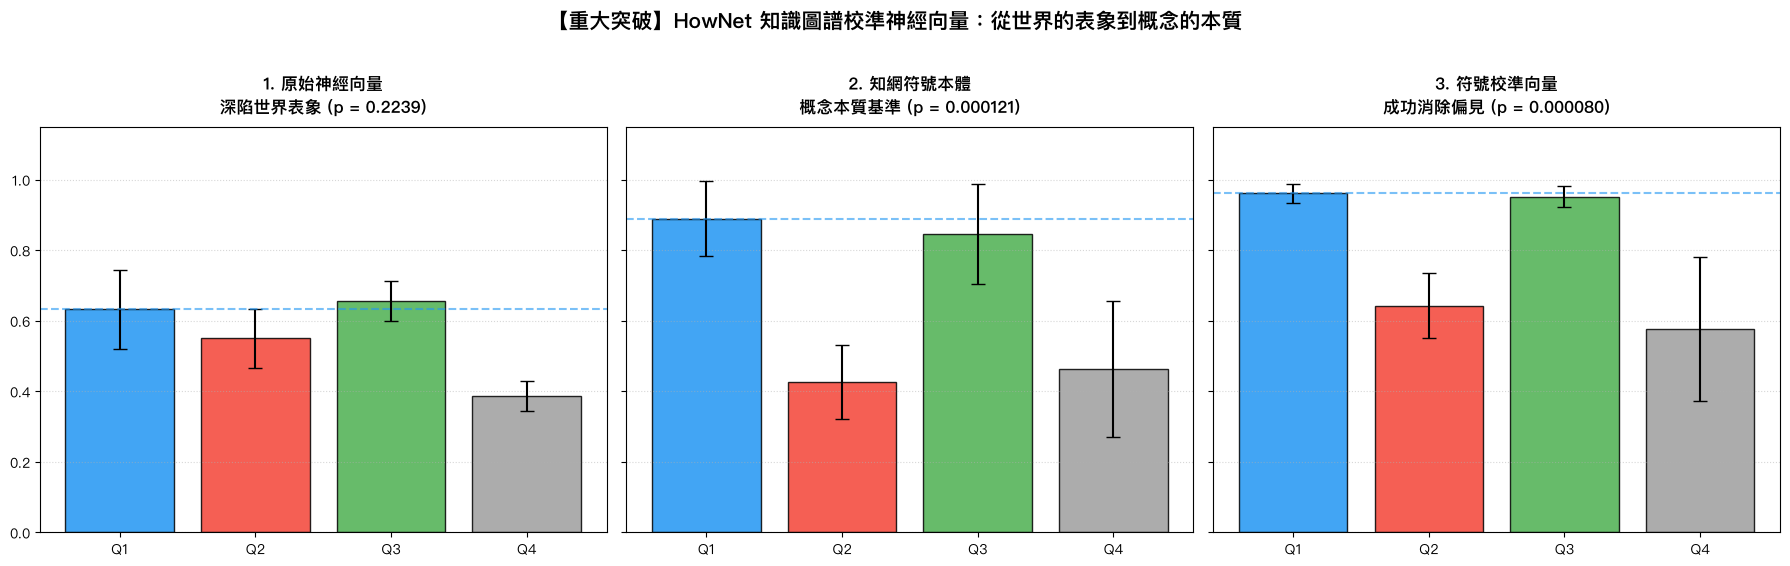

In [7]:
# 6. 產出三聯對比圖表
plt.rcParams["font.family"] = "PingFang TC"
plt.rcParams["axes.unicode_minus"] = False
COLORS = {"Q1": "#2196F3", "Q2": "#F44336", "Q3": "#4CAF50", "Q4": "#9E9E9E"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
panels = [
    ("llm_cosine", f"1. 原始神經向量\n深陷世界表象 (p = {p_raw:.4f})", axes[0]),
    ("hownet_similarity", f"2. 知網符號本體\n概念本質基準 (p = {p_how:.6f})", axes[1]),
    ("retrofitted_cosine", f"3. 符號校準向量\n成功消除偏見 (p = {p_ret:.6f})", axes[2])
]

for col, title, ax in panels:
    means = df.groupby("quadrant")[col].mean()
    stds = df.groupby("quadrant")[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=5,
           color=[COLORS[q] for q in means.index], alpha=0.85, edgecolor="black")
    ax.axhline(y=means["Q1"], color="#2196F3", linestyle="--", alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylim(0, 1.15)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.suptitle("【重大突破】HowNet 知識圖譜校準神經向量：從世界的表象到概念的本質", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
output_fig = RESULTS_DIR / "04_retrofitting_comparison.png"
plt.savefig(output_fig, dpi=180, bbox_inches="tight")
print(f"✅ 圖表已產出至: {output_fig}")
plt.show()